Descripción del Notebook:

En este notebook introductorio exploraremos los fundamentos del Transfer Learning utilizando la arquitectura MobileNetV2 preentrenada en ImageNet. Analizaremos cómo inspeccionar las capas base, eliminar la cabeza clasificadora original (include_top=False) y adaptar la red para una nueva tarea de clasificación. Al final del notebook generaremos un esquema visual representativo del modelo.

🐍 Importación de Librerías y Configuración

In [4]:
import os
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2

# Crear directorio para imágenes si no existe
os.makedirs('../image', exist_ok=True)
print("Versión de TensorFlow:", tf.__version__)

Versión de TensorFlow: 2.21.0


🐍 Parte 1: Carga e Inspección del Modelo Base

In [5]:
# Carga del modelo MobileNetV2 sin la capa superior de clasificación
base_model = MobileNetV2(
    input_shape=(224, 224, 3), include_top=False, weights='imagenet'
)

print(f'Número de capas en el modelo base: {len(base_model.layers)}')
print(f'Forma del tensor de salida: {base_model.output_shape}')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Número de capas en el modelo base: 154
Forma del tensor de salida: (None, 7, 7, 1280)


🐍 Parte 2: Construcción de la Cabeza Clasificadora

In [6]:
# Construcción de la arquitectura completa conectando la base a nuevas capas
inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(2, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,260,546 (8.62 MB)

 Trainable params: 2,226,434 (8.49 MB)

 Non-trainable params: 34,112 (133.25 KB)

🐍 Parte 3: Generación del Diagrama de la Arquitectura

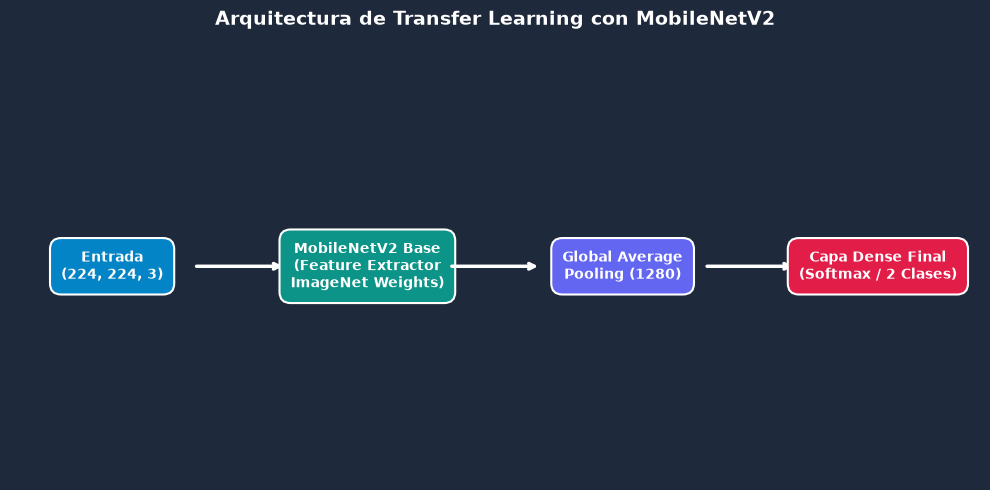

Imagen guardada en: ../image/arquitectura_mobilenetv2.png


In [7]:
fig, ax = plt.subplots(figsize=(10, 5), facecolor='#1e293b')
ax.set_facecolor('#1e293b')

boxes = [
    ('Entrada\n(224, 224, 3)', '#0284c7'),
    ('MobileNetV2 Base\n(Feature Extractor\nImageNet Weights)', '#0d9488'),
    ('Global Average\nPooling (1280)', '#6366f1'),
    ('Capa Dense Final\n(Softmax / 2 Clases)', '#e11d48'),
]

for i, (text, color) in enumerate(boxes):
  ax.text(
      i * 2.5,
      0.5,
      text,
      ha='center',
      va='center',
      color='white',
      weight='bold',
      bbox=dict(
          boxstyle='round,pad=0.8', facecolor=color, edgecolor='white', lw=1.5
      ),
  )
  if i < len(boxes) - 1:
    ax.annotate(
        '',
        xy=((i + 1) * 2.5 - 0.8, 0.5),
        xytext=(i * 2.5 + 0.8, 0.5),
        arrowprops=dict(arrowstyle='->', color='white', lw=2.5),
    )

ax.set_xlim(-1, 8.5)
ax.set_ylim(0, 1)
ax.axis('off')
plt.title(
    'Arquitectura de Transfer Learning con MobileNetV2',
    color='white',
    fontsize=14,
    pad=20,
    weight='bold',
)
plt.tight_layout()
plt.savefig(
    '../image/arquitectura_mobilenetv2.png',
    dpi=300,
    facecolor=fig.get_facecolor(),
)
plt.show()
print("Imagen guardada en: ../image/arquitectura_mobilenetv2.png")

Resumen de lo aprendido:

*   Carga de modelo convolucional preentrenado (MobileNetV2) sin su capa original de clasificación (include_top=False).

*   Adición de una capa de Global Average Pooling para reducir la dimensionalidad de los mapas de características a un vector de 1280 elementos.

*   Construimos un nuevo clasificador fully-connected y exportamos la figura arquitectura_mobilenetv2.png.